In [1]:
import numpy as np
import matplotlib.pyplot as plt
from psrqpy import QueryATNF

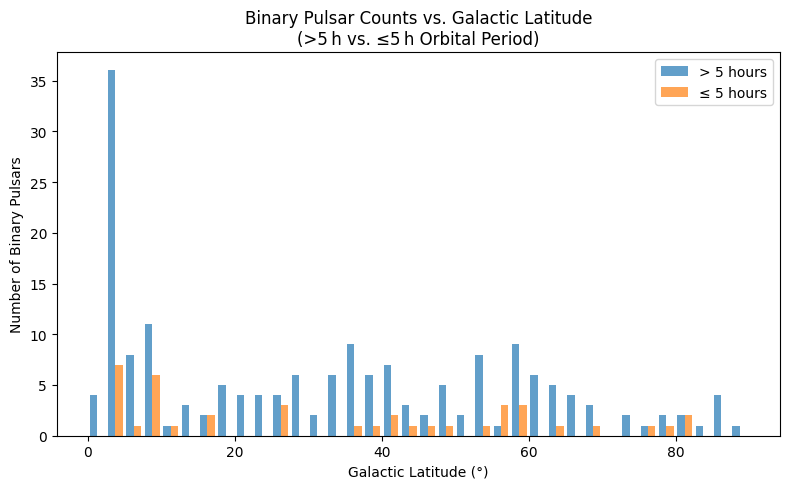

In [2]:
# 1. Pull PSRJ, PB (days), and GL (deg) into a DataFrame
query = QueryATNF(params=["PSRJ", "PB", "GL"])
df = query.pandas

# 2. Drop entries with missing PB or GL
df = df.dropna(subset=["PB", "GL"])

# 3. Convert PB → hours
df["PB_hours"] = df["PB"] * 24.0

# 4. Define masks for >5 h and ≤5 h
mask_long  = df["PB_hours"] > 5.0
mask_short = df["PB_hours"] <= 5.0

# 5. Extract galactic latitudes
gl_long  = df.loc[mask_long,  "GL"]
gl_short = df.loc[mask_short, "GL"]

# 6. Plot histograms with 5° bins from –90° to +90°
bins = np.linspace(0, 90, 37)
plt.figure(figsize=(8,5))
plt.hist(
    [gl_long, gl_short],
    bins=bins,
    label=["> 5 hours", "≤ 5 hours"],
    alpha=0.7
)
plt.xlabel("Galactic Latitude (°)")
plt.ylabel("Number of Binary Pulsars")
plt.title("Binary Pulsar Counts vs. Galactic Latitude\n(>5 h vs. ≤5 h Orbital Period)")
plt.legend()
plt.tight_layout()
plt.show()


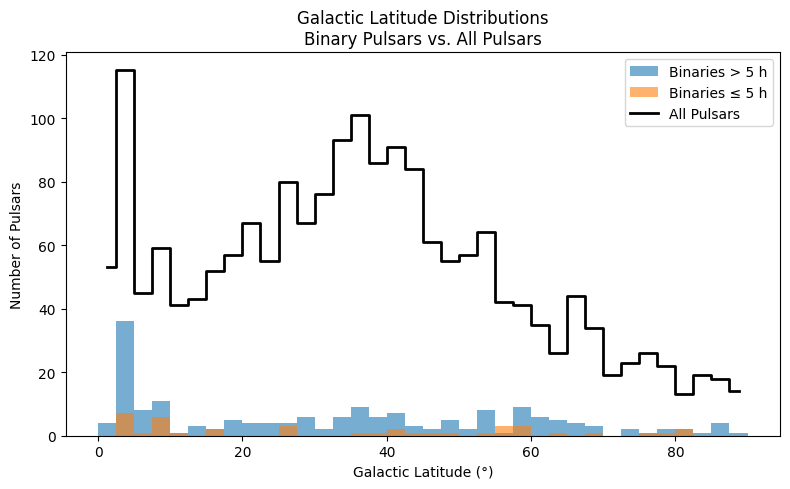

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from psrqpy import QueryATNF

# 1. Fetch binary systems (PB) + GL
bin_query = QueryATNF(params=["PSRJ", "PB", "GL"])
bin_df = bin_query.pandas.dropna(subset=["PB", "GL"])
bin_df["PB_hours"] = bin_df["PB"] * 24.0

# 2. Split binaries into >5 h and ≤5 h
gl_long  = bin_df.loc[bin_df["PB_hours"] >  5.0, "GL"]
gl_short = bin_df.loc[bin_df["PB_hours"] <= 5.0, "GL"]

# 3. Fetch all pulsars’ GL (including isolated)
all_query = QueryATNF(params=["PSRJ", "GL"])
all_df = all_query.pandas.dropna(subset=["GL"])
gl_all = all_df["GL"]

# 4. Define common bins (5° wide from –90° to +90°)
bins = np.linspace(0, 90, 37)

# 5. Compute histograms
counts_long,  _ = np.histogram(gl_long,  bins=bins)
counts_short, _ = np.histogram(gl_short, bins=bins)
counts_all,   _ = np.histogram(gl_all,    bins=bins)
bin_centers = 0.5*(bins[:-1] + bins[1:])

# 6. Plot
plt.figure(figsize=(8,5))

# Histograms for binaries (filled bars)
plt.hist(gl_long,  bins=bins, alpha=0.6, label="Binaries > 5 h")
plt.hist(gl_short, bins=bins, alpha=0.6, label="Binaries ≤ 5 h")

# Overlay total pulsar counts as a line
plt.plot(bin_centers, counts_all, drawstyle="steps-mid",
         linewidth=2, label="All Pulsars", color="k")

plt.xlabel("Galactic Latitude (°)")
plt.ylabel("Number of Pulsars")
plt.title("Galactic Latitude Distributions\nBinary Pulsars vs. All Pulsars")
plt.legend()
plt.tight_layout()
plt.show()


Mean recovered Pdot: 1.179e-14
Std of recovered Pdot: 1.391e-13
RMS relative error: 13957569.48


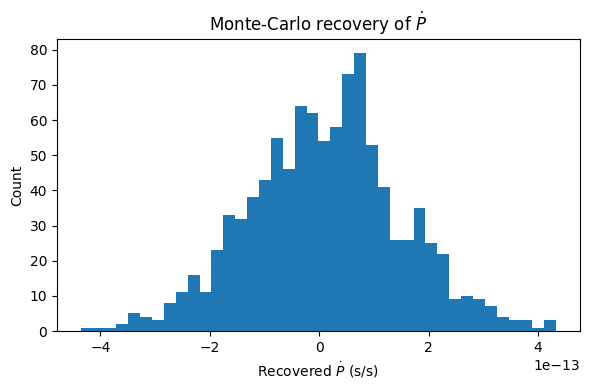

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap, sys, os, importlib.util, pandas as pd

def sigma_white(S_mJy=0.5, duty_cycle=0.1):
    """Radiometer + jitter white noise [s]."""
    return 0.7e-6 * (S_mJy / 0.5) ** -1 * (duty_cycle / 0.1) ** 0.5

def sigma_red(T_sec, A=1e-13, gamma=2.4):
    """Red (spin) noise RMS for epoch separation T [s]."""
    return 3e-9 * (A / 1e-13) * (T_sec / 86400) ** (gamma / 2)

def generate_toas(period, Pdot, epochs_days, S_mJy=0.5, duty_cycle=0.1,
                  A=1e-13, gamma=2.4, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    t_sec = np.asarray(epochs_days) * 86400.0
    true_P = period + Pdot * t_sec
    sig_W = sigma_white(S_mJy, duty_cycle)
    sig_R = sigma_red(t_sec, A, gamma)
    sig = np.sqrt(sig_W**2 + sig_R**2)
    noise = rng.normal(0.0, sig)
    meas_P = true_P + noise
    return t_sec, meas_P, sig

def fit_P_Pdot(times_sec, P_meas):
    A = np.vstack([np.ones_like(times_sec), times_sec]).T
    coef, *_ = np.linalg.lstsq(A, P_meas, rcond=None)
    return coef  # P0_est, Pdot_est

def run_monte_carlo(period=0.005, Pdot=1e-20, epochs_days=None, N=1000, **kwargs):
    if epochs_days is None:
        epochs_days = [0,3,10,30,90]
    rng = np.random.default_rng()
    P_est, Pdot_est = [], []
    for _ in range(N):
        t, Pm, _ = generate_toas(period, Pdot, epochs_days, rng=rng, **kwargs)
        P0_est, Pdot_hat = fit_P_Pdot(t, Pm)
        P_est.append(P0_est)
        Pdot_est.append(Pdot_hat)
    return np.asarray(P_est), np.asarray(Pdot_est)

#file_path = "/mnt/data/cadence_mc.py"
#with open(file_path, "w") as f:
#    f.write(script)

# load module
#spec = importlib.util.spec_from_file_location("cadence_mc", file_path)
#cadence_mc = importlib.util.module_from_spec(spec)
#sys.modules["cadence_mc"] = cadence_mc
#spec.loader.exec_module(cadence_mc)

# Run simulation
period = 0.005
Pdot_true = 1e-20
epochs = [0,3,10,30,90]
P_est, Pdot_est = run_monte_carlo(period=period, Pdot=Pdot_true,
                                            epochs_days=epochs, N=1000)

rel_err = (Pdot_est - Pdot_true)/Pdot_true
print(f"Mean recovered Pdot: {np.mean(Pdot_est):.3e}")
print(f"Std of recovered Pdot: {np.std(Pdot_est):.3e}")
print(f"RMS relative error: {np.sqrt(np.mean(rel_err**2)):.2f}")

# plot
plt.figure(figsize=(6,4))
plt.hist(Pdot_est, bins=40)
plt.xlabel("Recovered $\\dot P$ (s/s)")
plt.ylabel("Count")
plt.title("Monte‑Carlo recovery of $\\dot P$")
plt.tight_layout()



In [13]:
import psrqpy, pandas as pd

query = psrqpy.QueryATNF(params=['PSRJ','GL','GB','S1400', 'PB'],
                         psrtype="BINARY")
df = query.pandas

(array([], dtype=int64),)


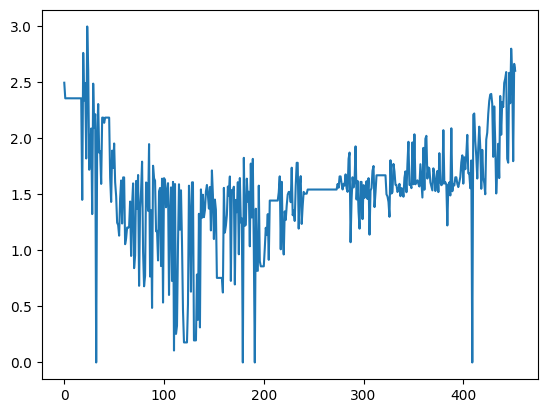

Error encountered at /project/cextern/healpix/src/cxx/Healpix_cxx/healpix_base.cc, line 888
(function I T_Healpix_Base<I>::loc2pix(double, double, double, bool) const [with I = long int])

must not happen

Error encountered at /project/cextern/healpix/src/cxx/Healpix_cxx/healpix_base.cc, line 888
(function I T_Healpix_Base<I>::loc2pix(double, double, double, bool) const [with I = long int])

must not happen

Error encountered at /project/cextern/healpix/src/cxx/Healpix_cxx/healpix_base.cc, line 888
(function I T_Healpix_Base<I>::loc2pix(double, double, double, bool) const [with I = long int])

must not happen

Error encountered at /project/cextern/healpix/src/cxx/Healpix_cxx/healpix_base.cc, line 888
(function I T_Healpix_Base<I>::loc2pix(double, double, double, bool) const [with I = long int])

must not happen



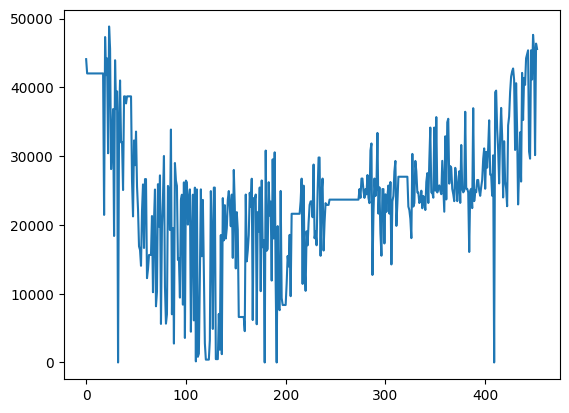

(49152,)


In [34]:
import healpy as hp, numpy as np

NSIDE = 64                     # ~1° pixels (good compromise)
npix  = hp.nside2npix(NSIDE)

# Bin the pulsars into pixels
theta = np.radians(90 - df['GB'])        # colatitude
theta = np.nan_to_num(theta, nan=0.0)        # replace NaN with 0
print(np.where(np.isnan(theta) == True))
plt.plot(theta)
plt.show()

phi = np.array(np.radians(df['GL']))
pix = hp.ang2pix(NSIDE, theta, phi)
pix[pix <= 0]  = 0

plt.plot(pix)
plt.show()

density = np.bincount(pix, minlength=npix)
area_sr = hp.nside2pixarea(NSIDE)        # sr per pixel
surf_dens = density / area_sr            # pulsars sr⁻¹

BEAM_SR = 10.6 * (np.pi/180)**2        # convert to steradians
lam_map   = surf_dens * BEAM_SR        # expected # of binaries
prob_map  = 1 - np.exp(-lam_map)       # P(k≥1)  (Poisson CDF)

print(prob_map.shape)


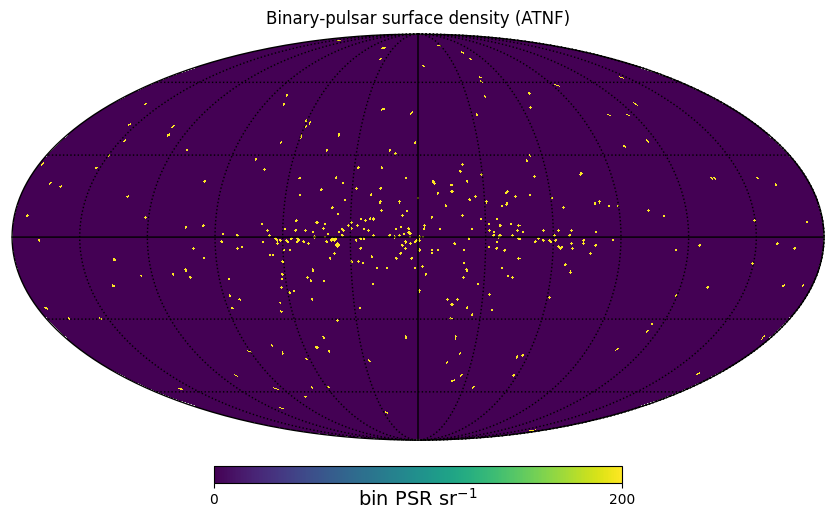

<Figure size 640x480 with 0 Axes>

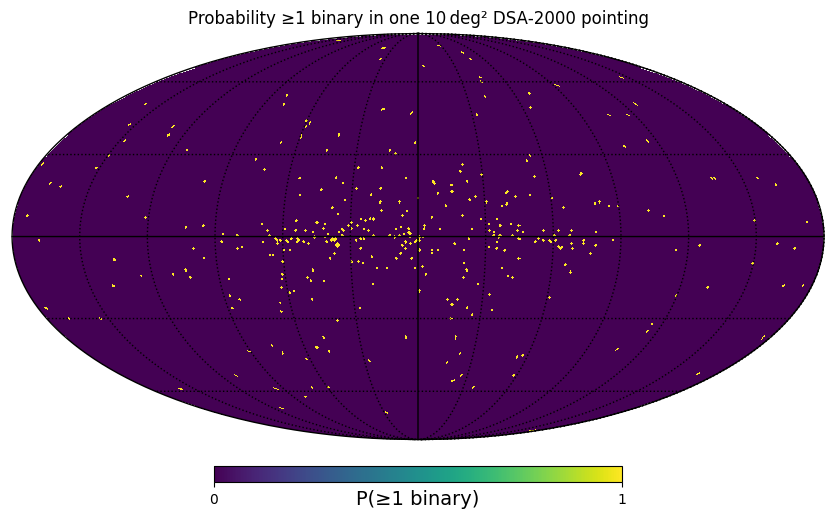

In [35]:
import matplotlib.pyplot as plt
hp.mollview(surf_dens, unit='bin PSR sr$^{-1}$',
            title='Binary‑pulsar surface density (ATNF)',
            min=0, max=200)
hp.graticule()
plt.figure()
hp.mollview(prob_map, unit='P(≥1 binary)',
            title='Probability ≥1 binary in one 10 deg² DSA‑2000 pointing',
            min=0, max=1, cmap='viridis')
hp.graticule()


In [11]:
import psrqpy, healpy as hp, numpy as np

# --- 1. ATNF query ----------------------------------------------------------
df = psrqpy.QueryATNF(params=['GL', 'GB', 'PB'], condition="S1400>0.05").pandas

# --- 2. Density map ---------------------------------------------------------
NSIDE = 64
theta, phi = np.radians(90 - df['GB']), np.radians(df['GL'])
pix = hp.ang2pix(NSIDE, theta, phi)
rho = np.bincount(pix, minlength=hp.nside2npix(NSIDE))
rho_flt = np.array([float(i) for i in rho])   # sr^-1
rho_flt /= hp.nside2pixarea(NSIDE)

# --- 3. Probability map -----------------------------------------------------
BEAM_SR = 10.6 * (np.pi/180)**2
lam  = rho * BEAM_SR
prob = 1 - np.exp(-lam)

# --- 4. Query probability for your pointing --------------------------------
def p_binary(l_deg, b_deg):
    pix = hp.ang2pix(NSIDE,
                     np.radians(90 - b_deg),
                     np.radians(l_deg))
    return prob[pix]

print("P(at least 1 binary) at l=45°, b=2°  → ",
      p_binary(45, 2))


P(at least 1 binary) at l=45°, b=2°  →  0.003223737214311684


In [33]:
import healpy as hp, numpy as np
NSIDE = 64
theta, phi = np.radians(90 - df['GB']), np.radians(df['GL'])
pix = hp.ang2pix(NSIDE, theta, phi)
rho   = np.bincount(pix, minlength=hp.nside2npix(NSIDE))
rho  /= hp.nside2pixarea(NSIDE)   # sr^-1



UFuncTypeError: Cannot cast ufunc 'divide' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'